# Sentiment by Version

In this notebook I explore whether user sentiment improved as Beli delivered successive updates. The raw data has too many distinct versions to analyze cleanly, most carry only a handful of reviews, so I collapsed sub-versions into their major release, leaving 9 version groups with enough reviews each to compare.

The result is counterintuitive: negativity *rose* across versions rather than falling. I test whether that increase is real and then unpack what's driving it — which turns out to say as much about who leaves reviews as about the app itself.

In [68]:
import pandas as pd
df = pd.read_csv("data/tagged_reviews.csv")
version_df = df[df["version"].notna()].copy()
version_df.head()

,source,text,rating,version,date,title,storefront,author,review_id,theme_tags
0,app_store,"PLEASE bring back the old smaller pictures, th...",1,9.3.1,NaN,NEW UI SUCKS,us,wsonja112,0,"{""feature requests"": ""negative""}"
1,app_store,The UI is clunky and requiring invites to use ...,1,9.3.1,NaN,Poor design and scammy behavior,us,scknight4,1,"{""forced invite wall"": ""negative"", ""performanc..."
2,app_store,It is good at what it does and it’s free nd no...,5,9.3.1,NaN,Happy,us,Gstarbanana,2,"{""positive overall experience"": ""positive""}"
3,app_store,I have to share that I am drifting away from t...,2,9.3.1,NaN,Worse than Google Maps,us,brenda y. g.,3,"{""ranking and rating mechanics"": ""negative"", ""..."
4,app_store,All I want to do is find a restaurant near my ...,1,9.3.0,NaN,Useless,us,DestructoTex,4,"{""forced invite wall"": ""negative"", ""map and na..."


*The cell below shows that most versions have only a handful of reviews, which is why I collapsed sub-versions into major releases before analyzing.*

In [69]:
version_df.groupby(["version"]).size().reset_index(name="n_reviews")

,version,n_reviews
0,1.9.12,1
1,1.9.15,1
2,1.9.18,1
3,1.9.19,1
4,1.9.25,1
...,...,...
258,9.1.1,1
259,9.1.2,8
260,9.2.0,3
261,9.3.0,3


In [70]:
themes_long = pd.read_csv('data/themes_long.csv')

tl = themes_long.merge(
    version_df[["review_id", "version"]],
    on="review_id",
    how="inner",  
)

tl["is_negative"] = tl["sentiment"] == "negative"

tl.head()

,review_id,source,theme,sentiment,version,is_negative
0,0,app_store,feature requests,negative,9.3.1,True
1,0,app_store,feature requests,negative,9.3.1,True
2,1,app_store,forced invite wall,negative,9.3.1,True
3,1,app_store,forced invite wall,negative,9.3.1,True
4,1,app_store,performance and clunkiness,negative,9.3.1,True


In [71]:
tl["version_group"] = tl["version"].astype(str).str.split(".").str[:1].str.join(".")
by_version = (tl.groupby("version_group")
                .agg(n=("sentiment", "size"),
                     pct_negative=("is_negative", "mean"))
                .reset_index())
by_version["pct_negative"] = (by_version["pct_negative"] * 100).round(1)
by_version

,version_group,n,pct_negative
0,1,19,31.6
1,2,116,21.6
2,3,124,31.5
3,4,77,41.6
4,5,218,44.5
5,6,169,44.4
6,7,809,55.5
7,8,678,72.7
8,9,167,79.0


The line graph below shows negativity rising across app versions. This is a counterintuitive result, since I'd expect sentiment to improve as the app matures and bugs get fixed. One thing is worth checking before drawing any conclusion: whether the increase is statistically real (rather than noise from the small early-version samples).

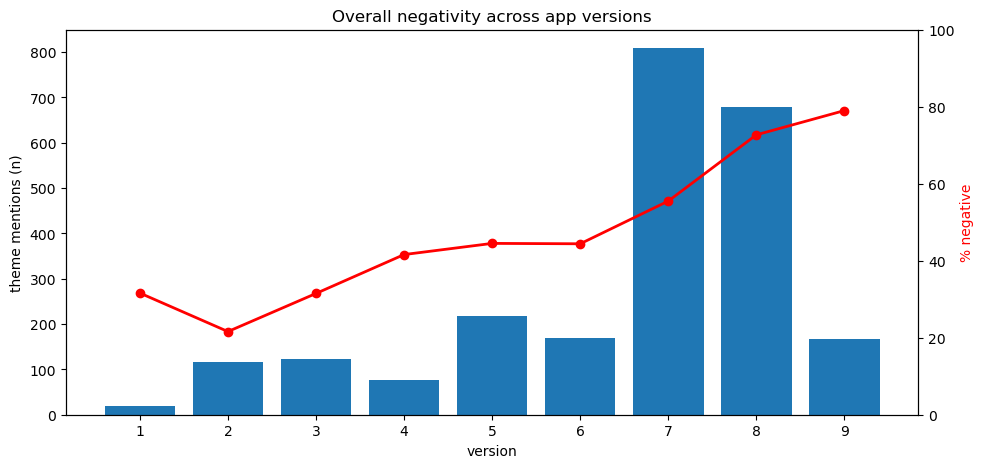

In [82]:
import matplotlib.pyplot as plt

plot_df = by_version.sort_values("version_group")

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.bar(plot_df["version_group"], plot_df["n"])
ax1.set_ylabel("theme mentions (n)")
ax1.set_xlabel("version")

ax2 = ax1.twinx()
ax2.plot(by_version['version_group'],by_version['pct_negative'], color="red", marker="o", lw=2)
ax2.set_ylim(0, 100)
ax2.set_ylabel("% negative", color="red")

ax1.set_title("Overall negativity across app versions")
plt.show()

*The cells below run a permutation test on whether negativity differs between Beli's earlier and later versions. I split the versions into two eras — early (1–5) and late (6–9) — and test whether the gap in negativity between them is real or could be explained by chance.*
## The Test

- **H0 (null):** the two eras have the same negativity rate; the observed gap is chance.
- **H1 (alternative):** the two eras have different negativity rates.

**Method:** a permutation test on the negativity rate. If the era labels don't matter, I can shuffle them and the gap should be near zero. Repeating that many times builds the null distribution, which I compare the real gap against.

In [80]:
import numpy as np

tl["version_group"] = pd.to_numeric(tl["version_group"])

late_versions = [6, 7, 8, 9]

period = tl.copy()
period["era"] = "early"
period.loc[period["version_group"].isin(late_versions), "era"] = "late"

period.groupby("era")["is_negative"].agg(n="size", pct_negative="mean")

,n,pct_negative
era,,
early,554,0.359206
late,1823,0.630280


In [97]:
rng = np.random.default_rng(42)

is_negative = period["is_negative"]
is_late = (period["era"] == "late")


def negativity_gap(tbl, late):
    """Late negativity − early negativity, in percentage points."""
    return (tbl[late].mean() - tbl[~late].mean()) * 100


def one_simulated_gap(tbl, late):
    """Shuffle the era labels once, then recompute the gap."""
    return negativity_gap(tbl, rng.permutation(late))

In [98]:
observed_diff = negativity_gap(is_negative, is_late)
print(f"Observed difference (late − early): {observed_diff:.1f} pp")

Observed difference (late − early): 27.1 pp


In [83]:
n_iter = 10000
simulated_gaps = np.array([
    one_simulated_gap(is_negative, is_late)
    for i in range(n_iter)
])

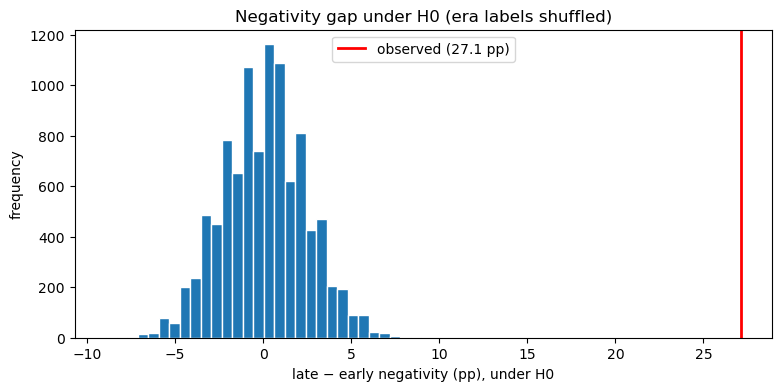

In [96]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(simulated_gaps, bins=30, edgecolor="white")
ax.axvline(observed_diff, color="red", lw=2, label=f"observed ({observed_diff:.1f} pp)")
ax.set_xlabel("late − early negativity (pp), under H0")
ax.set_ylabel("frequency")
ax.set_title("Negativity gap under H0 (era labels shuffled)")
ax.legend()
plt.show()

In [95]:
p_value = np.mean(np.abs(simulated_gaps) >= np.abs(observed_diff))
print(p_value)

0.0


The histogram is the null distribution: the gaps I'd get if era didn't matter, built by shuffling the labels 10,000 times. The red line is the gap I actually observed. It sits far outside the shuffled distribution, which is why the p-value is so small. A gap this large essentially never arises by chance.

## Permutation Results

The test confirms the negativity gap between early and late versions is significant (p < 0.0001), so it's unlikely to be sampling noise. But it doesn't explain why the gap exists. Review volume grew sharply across versions (from ~19 to ~800 reviews), which probably reflects a broadening, more critical reviewer base — and the test can't rule that out. Telling apart a genuine decline in the app from a shift in who reviews it would need evidence this test doesn't provide.

The App Store sampling is another caveat. The RSS feed only returns the most recent reviews (capped at ~500), not the full review base, so the dataset over-represents certain versions and time periods rather than sampling evenly across the app's history.

## Conclusion

The rising negativity across versions is a real effect (the permutation test rules out chance), but it's hard to attribute cleanly. The comment base differs too much between versions to compare directly: early versions have far fewer reviews, likely from a different, earlier-adopter audience than the later cohorts. Voluntary response bias may also play a role - people tend to review when they feel strongly, either positive or negative, so the sample over-represents extreme opinions rather than the typical user. The trend tells that something shifted, but not whether the app itself declined or simply who was reviewing it.

# Sentiment by Quarter (Google Play)

After the sentiment by version analysis, I wanted to look at sentiment over calendar time — partly to see whether the trend tracks when reviews were written rather than which version they target, and partly because time and version tell different stories (a time trend can pick up external events, like press or a viral moment, that aren't tied to a release).

One important limitation up front: this analysis covers **Google Play only**. The App Store RSS feed doesn't expose the date a review was written, so all 562 App Store reviews are excluded, leaving ~262 dated Google Play reviews. This is therefore the sentiment trend of Beli's *Android* reviewers, not the full user base, and the two platforms may not move together.

Because the dated reviews are sparse (often single digits per month), I bucket by **quarter** rather than month, so each point rests on enough reviews to be meaningful.

In [74]:
df = pd.read_csv("data/themes_long.csv")
gp = df[df['source'] == 'google_play']

tr = pd.read_csv("data/tagged_reviews.csv")
tr = tr[tr['source'] == 'google_play']
dates = tr[['date', 'review_id']]

gp_dates = gp.merge(dates, on='review_id', how='right')
gp_dates

,review_id,source,theme,sentiment,date
0,0,google_play,positive overall experience,negative,2026-06-21 09:32:35
1,0,google_play,performance and clunkiness,negative,2026-06-21 09:32:35
2,0,google_play,map and navigation,negative,2026-06-21 09:32:35
3,1,google_play,forced invite wall,negative,2026-06-20 17:25:18
4,1,google_play,ranking and rating mechanics,negative,2026-06-20 17:25:18
...,...,...,...,...,...
482,260,google_play,positive overall experience,positive,2022-11-02 14:23:31
483,260,google_play,forced invite wall,positive,2022-11-02 14:23:31
484,261,NaN,NaN,NaN,2022-10-29 21:06:53
485,262,google_play,performance and clunkiness,negative,2022-10-19 03:26:30


In [75]:
gp_dates['is_negative'] = gp_dates['sentiment'] == 'negative'
gp_dates['date'] = pd.to_datetime(gp_dates["date"])
gp_dates["quarter"] = gp_dates["date"].dt.to_period("Q").astype(str)
gp_quarter = gp_dates[['source', 'is_negative', 'quarter']]
gp_quarter

,source,is_negative,quarter
0,google_play,True,2026Q2
1,google_play,True,2026Q2
2,google_play,True,2026Q2
3,google_play,True,2026Q2
4,google_play,True,2026Q2
...,...,...,...
482,google_play,False,2022Q4
483,google_play,False,2022Q4
484,NaN,False,2022Q4
485,google_play,True,2022Q4


In [76]:
by_quarter = gp_quarter.groupby('quarter').agg(n=('source', 'size'), pct_negative=('is_negative', 'mean')).reset_index()
by_quarter["pct_negative"] = (by_quarter["pct_negative"] * 100).round(1)
by_quarter

,quarter,n,pct_negative
0,2022Q4,10,30.0
1,2023Q1,18,11.1
2,2023Q2,14,14.3
3,2023Q3,14,21.4
4,2023Q4,27,37.0
5,2024Q1,18,50.0
6,2024Q2,27,33.3
7,2024Q3,36,50.0
8,2024Q4,36,55.6
9,2025Q1,39,53.8


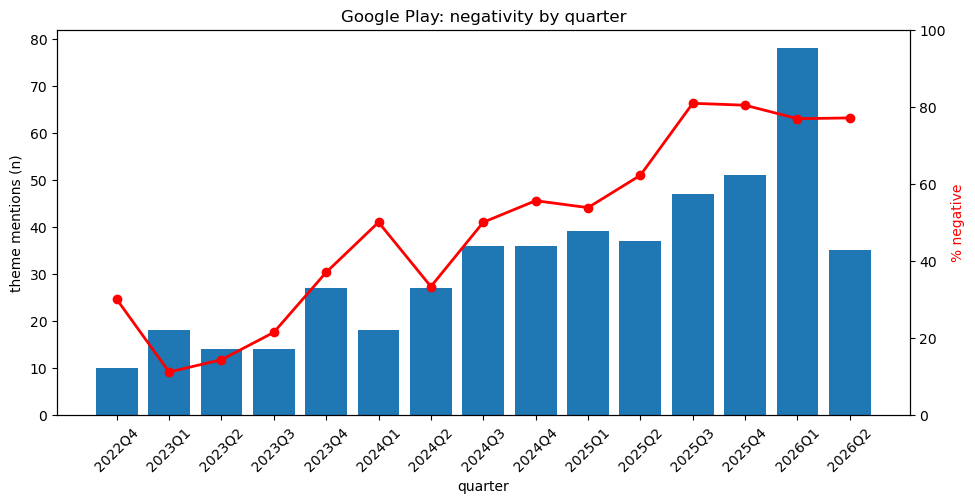

In [77]:
fig, ax1 = plt.subplots(figsize=(11,5))

ax1.bar(by_quarter["quarter"], by_quarter["n"])
ax1.set_ylabel("theme mentions (n)")
ax1.set_xlabel("quarter")

ax2 = ax1.twinx()
ax2.plot(by_quarter["quarter"], by_quarter["pct_negative"], color="red", marker="o", lw=2)
ax2.set_ylabel("% negative", color="red")
ax2.set_ylim(0, 100)

ax1.tick_params(axis="x", rotation=45)
ax1.set_title("Google Play: negativity by quarter")
plt.show()

The quarterly trend closely mirrors the version analysis: percent negative descreases initially, then rises progressively over time. This convergence is expected. Later reviews target later versions, so the two axes are largely capturing the same underlying shift rather than two independent factors.